In [1]:
import torch; torch.manual_seed(0)
import torch.nn as nn
import torch.nn.functional as F
import torch.utils
import torch.distributions
import torchvision
import numpy as np
import matplotlib.pyplot as plt; plt.rcParams['figure.dpi'] = 200
from afqinsight import AFQDataset
from afqinsight.nn.utils import prep_pytorch_data
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from torch.distributions.normal import Normal
from sklearn.decomposition import PCA
import afqinsight.augmentation as aug
from afqinsight.nn.pt_models import Conv1DAutoencoder
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
import sys 
sys.path.insert(1, '/Users/samchou/AFQ-Insight-Autoencoder-Plotting/Experiment_Utils')
# sys.path.insert(1, '/mmfs1/gscratch/nrdg/samchou/AFQ-Insight-Autoencoder-Experiments/Experiment_Utils')
from utils import select_device, prep_fa_dataset, prep_first_tract_data, prep_fa_flattned_data, prep_fa_flattened_remapped_data, GradReverse
from models import Conv1DVariationalAutoencoder_fa, AgePredictorCNN, SitePredictorCNN, CombinedVAE_Predictors

In [3]:
device = select_device()

Using device: mps

Using MPS backend on macOS. (Detailed memory info may not be available.)


In [4]:
dataset = AFQDataset.from_study('hbn')
torch_dataset, train_loader, test_loader, val_loader = prep_pytorch_data(dataset,batch_size=256)  
gt_shape = torch_dataset[0][1].size()[0]
sequence_length = torch_dataset[0][0].size()[0]  # 48
in_channels = torch_dataset[0][0].size()[1]  # 100


File /Users/samchou/.cache/afq-insight/hbn/subjects.tsv exists.
File /Users/samchou/.cache/afq-insight/hbn/nodes.csv exists.


/Users/samchou/src/nrdg/AFQ-Insight/afqinsight/transform.py:144: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  features = interpolated.stack(["subjectID", "tractID", "metric"]).unstack(


In [5]:
site_idx = dataset.target_cols.index('scan_site_id')
age_idx = dataset.target_cols.index('age')

In [6]:
unique_sites = np.unique(torch_dataset.y[:, site_idx])
print(f"Unique site values found: {unique_sites}")
site_map = {float(site): i for i, site in enumerate(sorted(unique_sites))}
print(f"Created site map: {site_map}")
num_sites = len(site_map)
print(f"Number of unique sites (classes): {num_sites}")


Unique site values found: [0. 1. 3. 4.]
Created site map: {0.0: 0, 1.0: 1, 3.0: 2, 4.0: 3}
Number of unique sites (classes): 4


In [7]:
torch_dataset, all_tracts_train_loader, all_tracts_test_loader, all_tracts_val_loader = prep_fa_flattned_data(dataset, batch_size=128)


In [8]:
print("Preparing initial PyTorch data loaders...")
try:
    # Assuming prep_pytorch_data returns torch_dataset, train_loader, test_loader, val_loader
    # If it returns datasets, create loaders here.
    # Adapt this call based on the actual signature and return values of your prep_pytorch_data
    prep_output = prep_fa_flattened_remapped_data(dataset, batch_size=128)
    if len(prep_output) == 4:
        _, train_loader_raw, test_loader_raw, val_loader_raw = prep_output
    else:
        raise ValueError(f"Expected 4 return values from prep_pytorch_data, got {len(prep_output)}")

    print("Initial data loaders prepared.")
except Exception as e:
     print(f"Error calling prep_pytorch_data: {e}")
     print("Ensure the function exists and returns DataLoaders or required components.")
     sys.exit(1)

Preparing initial PyTorch data loaders...
Remapping prep: Using age index 0, site index 2 from ['age', 'sex', 'scan_site_id']
Using site map: {0.0: 0.0, 1.0: 1.0, 3.0: 2.0, 4.0: 3.0}
Creating remapped datasets...
Creating final DataLoaders...
prep_fa_flattened_remapped_data complete.
Initial data loaders prepared.


In [9]:
# Option 1: Extract from filename if your filename format is consistent
import re
model_path = "model_weights/combo_ld32_drV0.0_drA0.0_drS0.0_wr1.0_wkl1.0_wa5.0_ws2.0.pth"
# First load just into CPU to inspect it
temp_state_dict = torch.load(model_path, map_location='cpu')
# Print keys with their shapes
for key, param in temp_state_dict.items():
    if 'site_predictor' in key:
        print(f"{key}: {param.shape}")

site_predictor.conv1.weight: torch.Size([32, 1, 5])
site_predictor.conv1.bias: torch.Size([32])
site_predictor.bn1.weight: torch.Size([32])
site_predictor.bn1.bias: torch.Size([32])
site_predictor.bn1.running_mean: torch.Size([32])
site_predictor.bn1.running_var: torch.Size([32])
site_predictor.bn1.num_batches_tracked: torch.Size([])
site_predictor.conv2.weight: torch.Size([64, 32, 3])
site_predictor.conv2.bias: torch.Size([64])
site_predictor.bn2.weight: torch.Size([64])
site_predictor.bn2.bias: torch.Size([64])
site_predictor.bn2.running_mean: torch.Size([64])
site_predictor.bn2.running_var: torch.Size([64])
site_predictor.bn2.num_batches_tracked: torch.Size([])
site_predictor.conv3.weight: torch.Size([128, 64, 3])
site_predictor.conv3.bias: torch.Size([128])
site_predictor.bn3.weight: torch.Size([128])
site_predictor.bn3.bias: torch.Size([128])
site_predictor.bn3.running_mean: torch.Size([128])
site_predictor.bn3.running_var: torch.Size([128])
site_predictor.bn3.num_batches_tracked:

/var/folders/gc/z2m2_nxj4qlf83r8bq6hz_240000gn/T/ipykernel_62012/3831378330.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  temp_state_dict = torch.load(model_path, map_

Reconstructed shape: torch.Size([128, 1, 50])
Mean shape: torch.Size([128, 32])
Logvar shape: torch.Size([128, 32])
Age predictions shape: tensor([12.4641])
Site predictions shape: tensor([ 0.2571, -1.5611,  0.4904, -0.1996])
age real tensor(16.4893)
site real tensor(3.)


/var/folders/gc/z2m2_nxj4qlf83r8bq6hz_240000gn/T/ipykernel_62012/475262634.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_locat

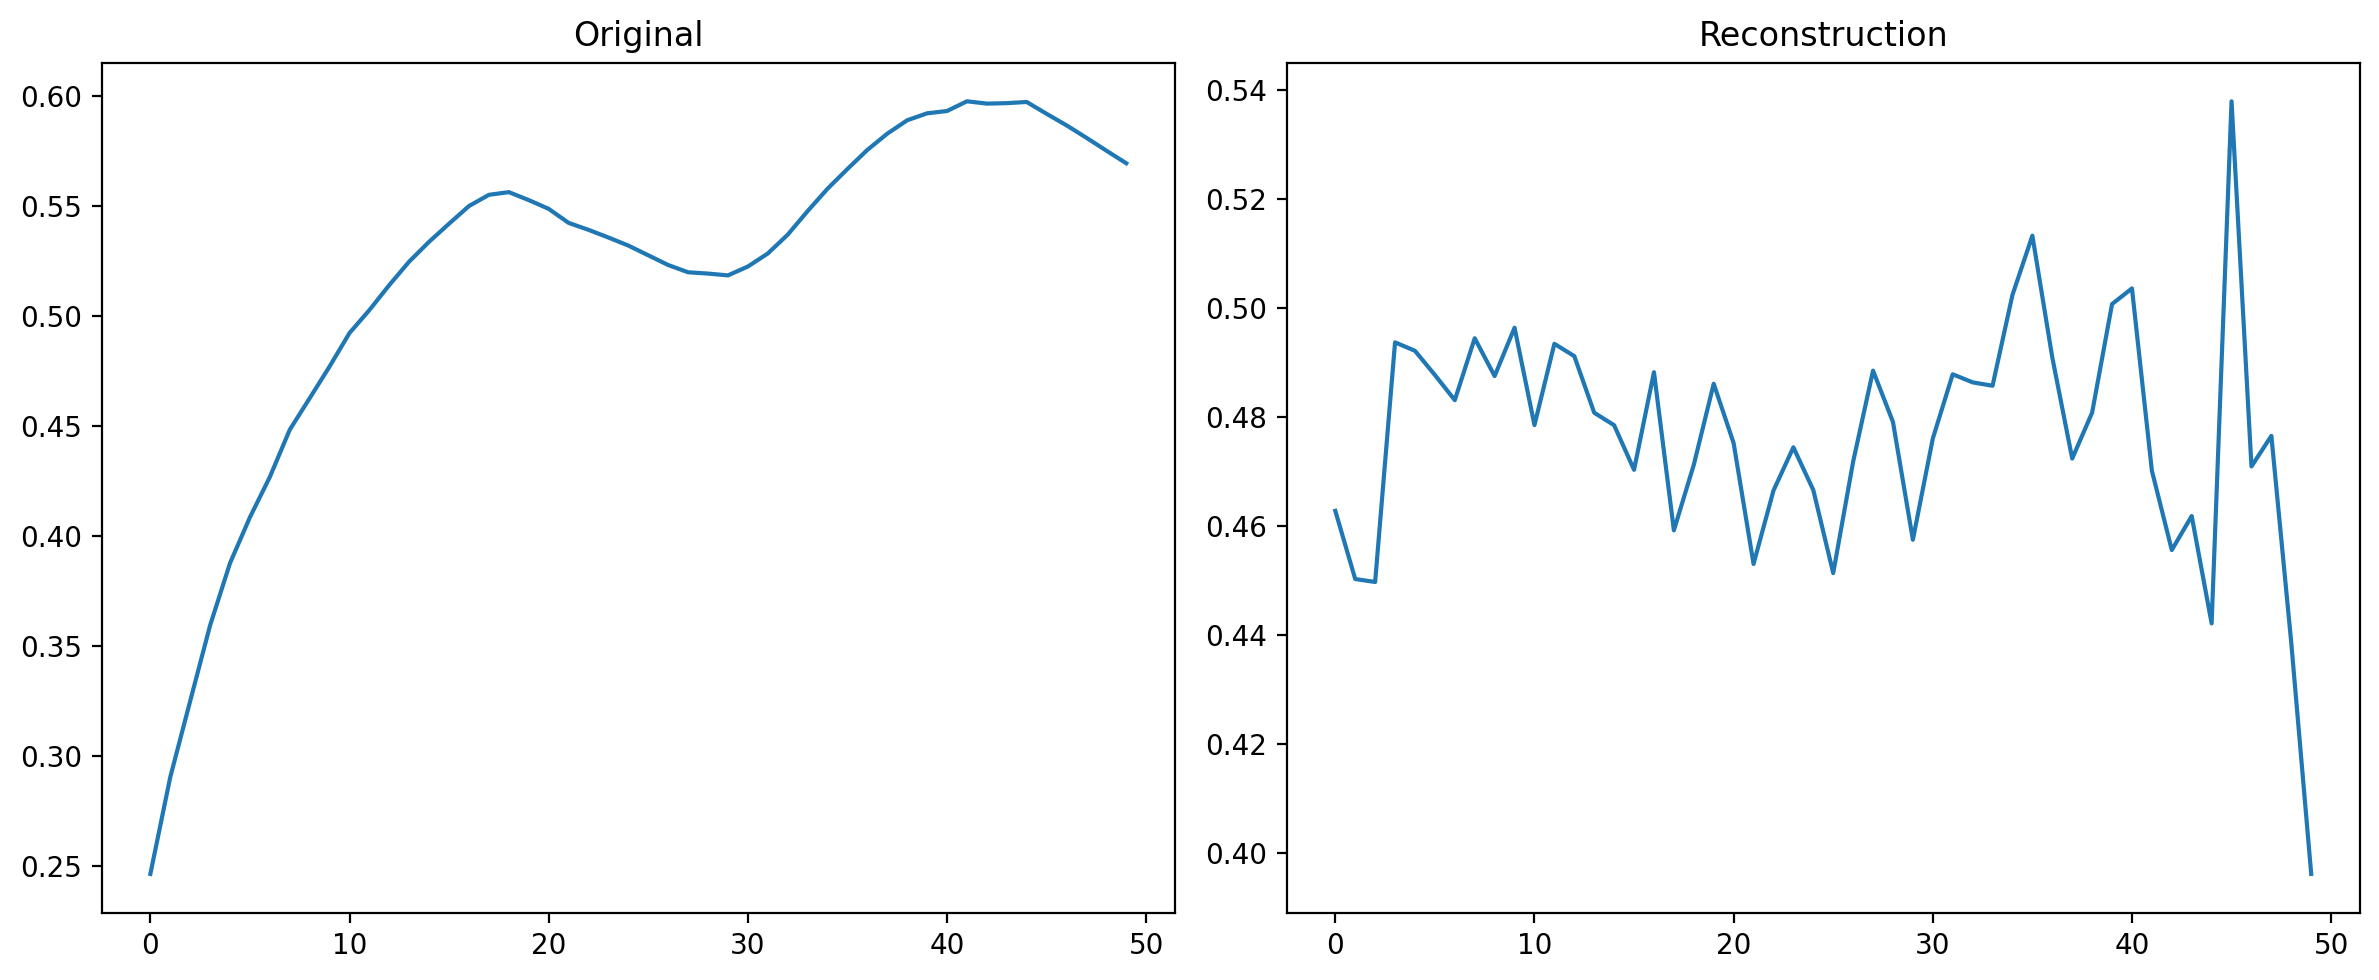

No age predictions available
No site predictions available


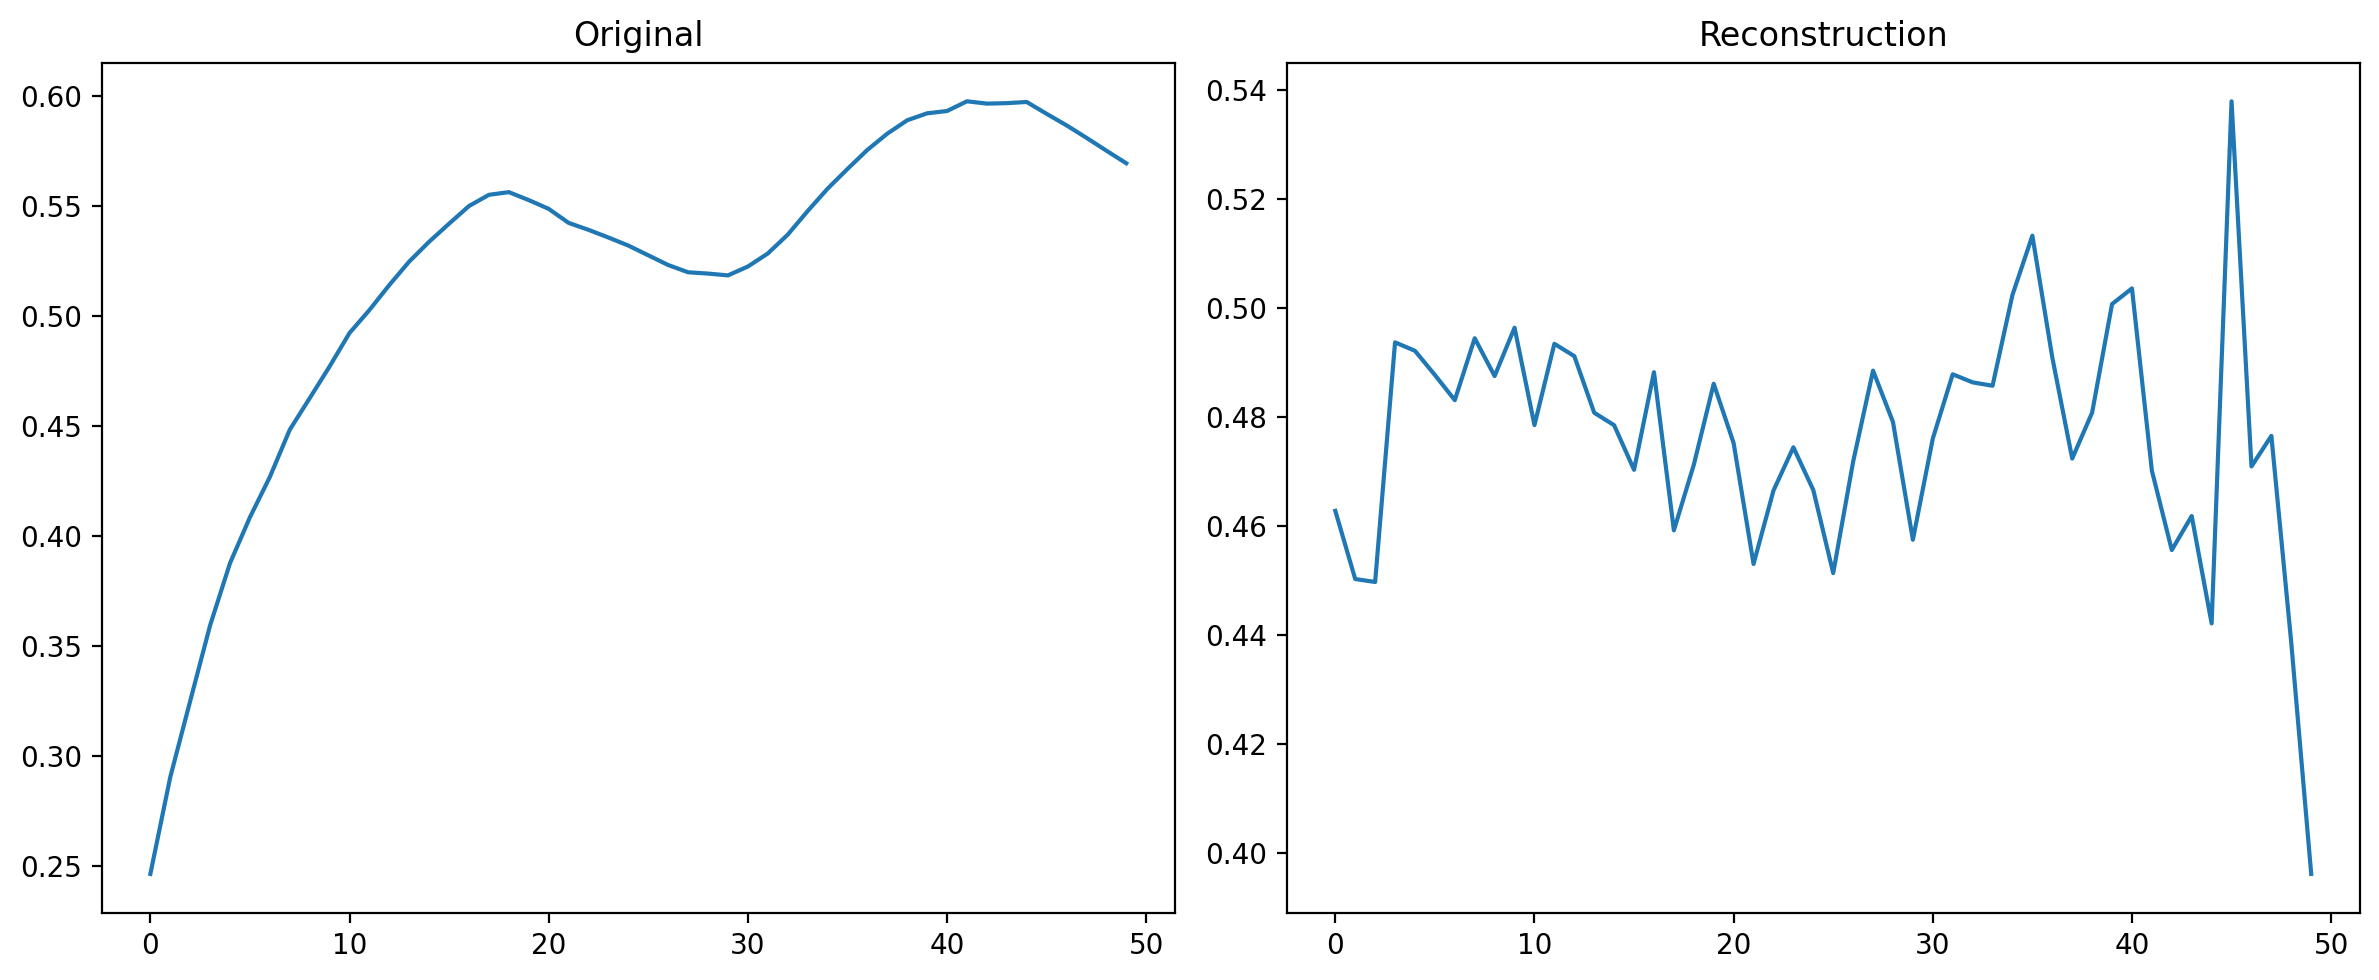

No age predictions available
No site predictions available


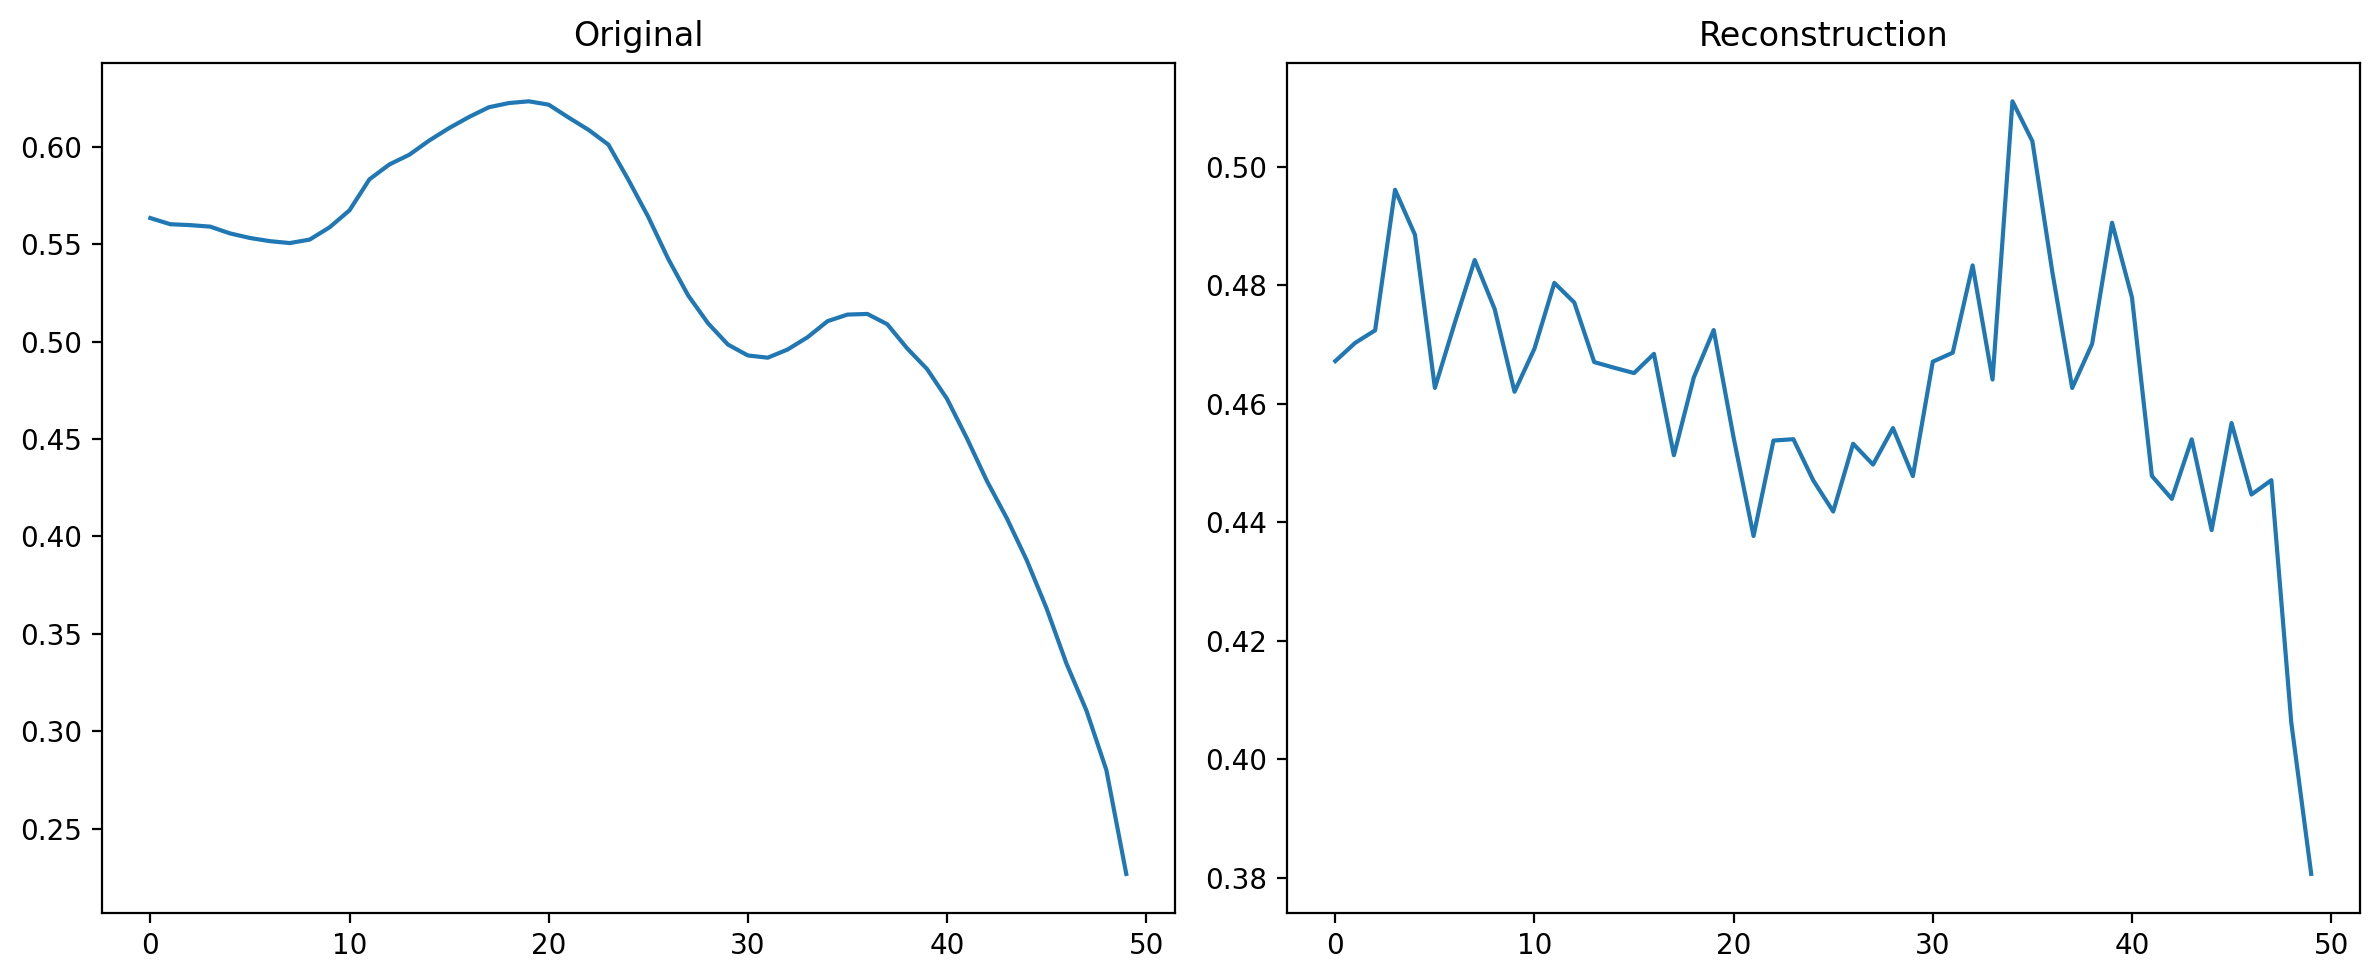

No age predictions available
No site predictions available


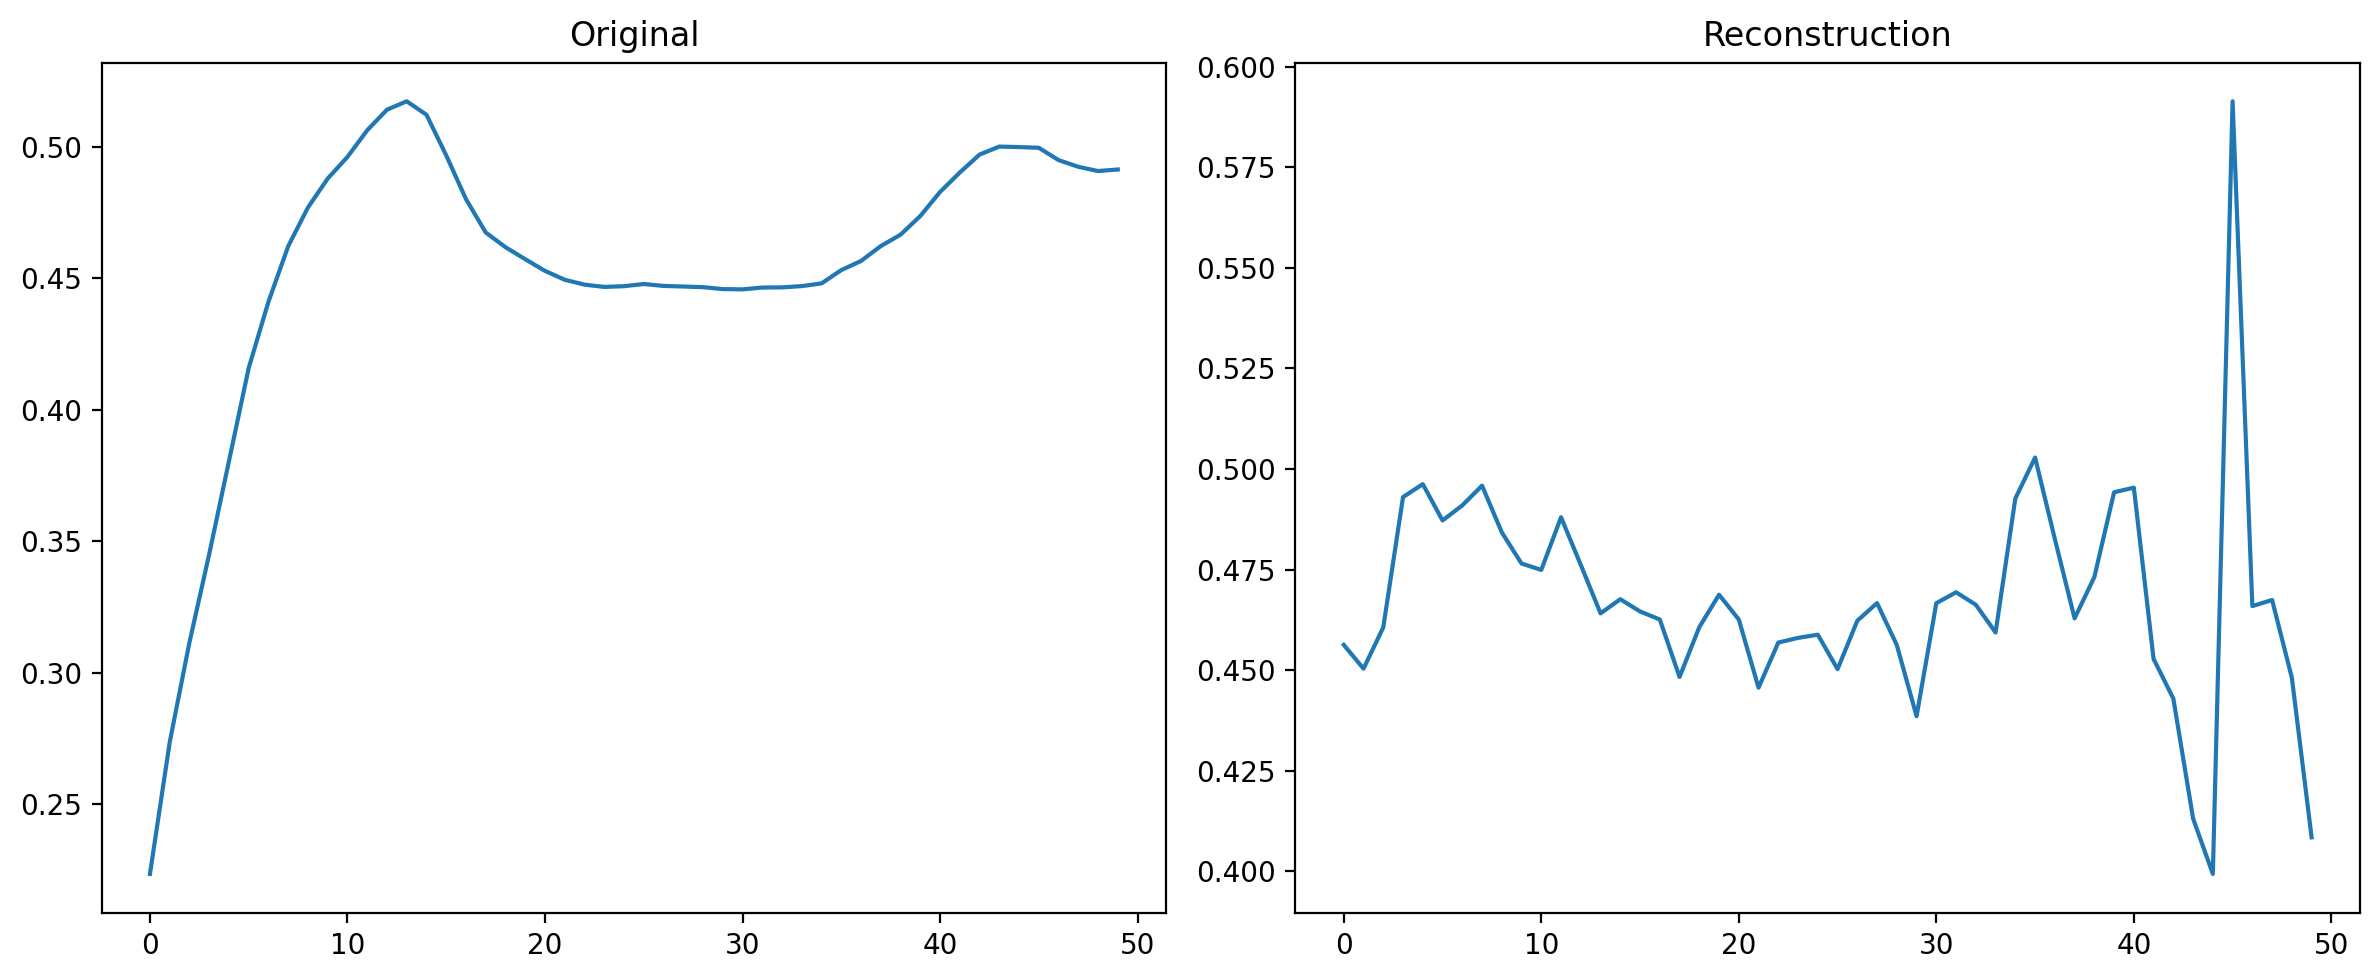

No age predictions available
No site predictions available


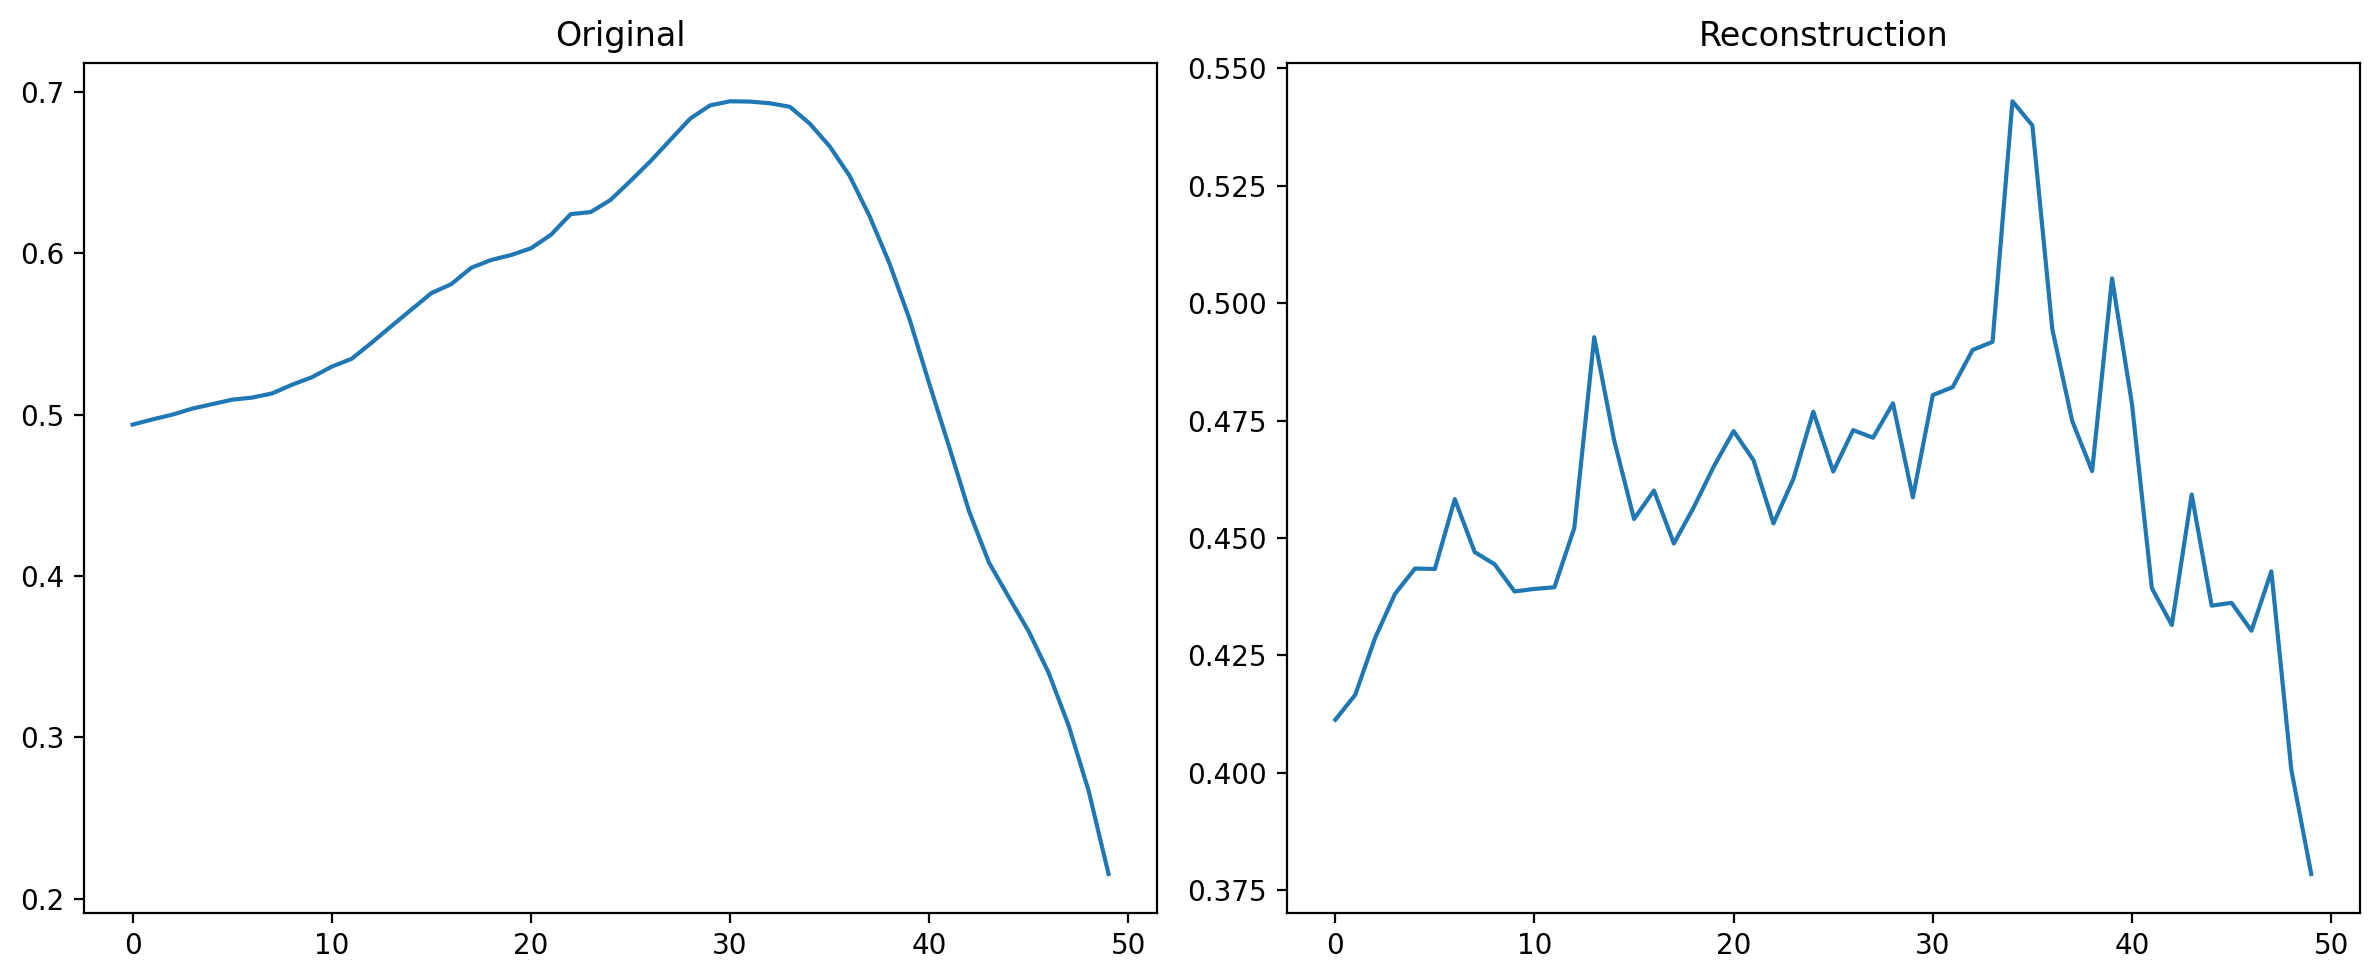

No age predictions available
No site predictions available


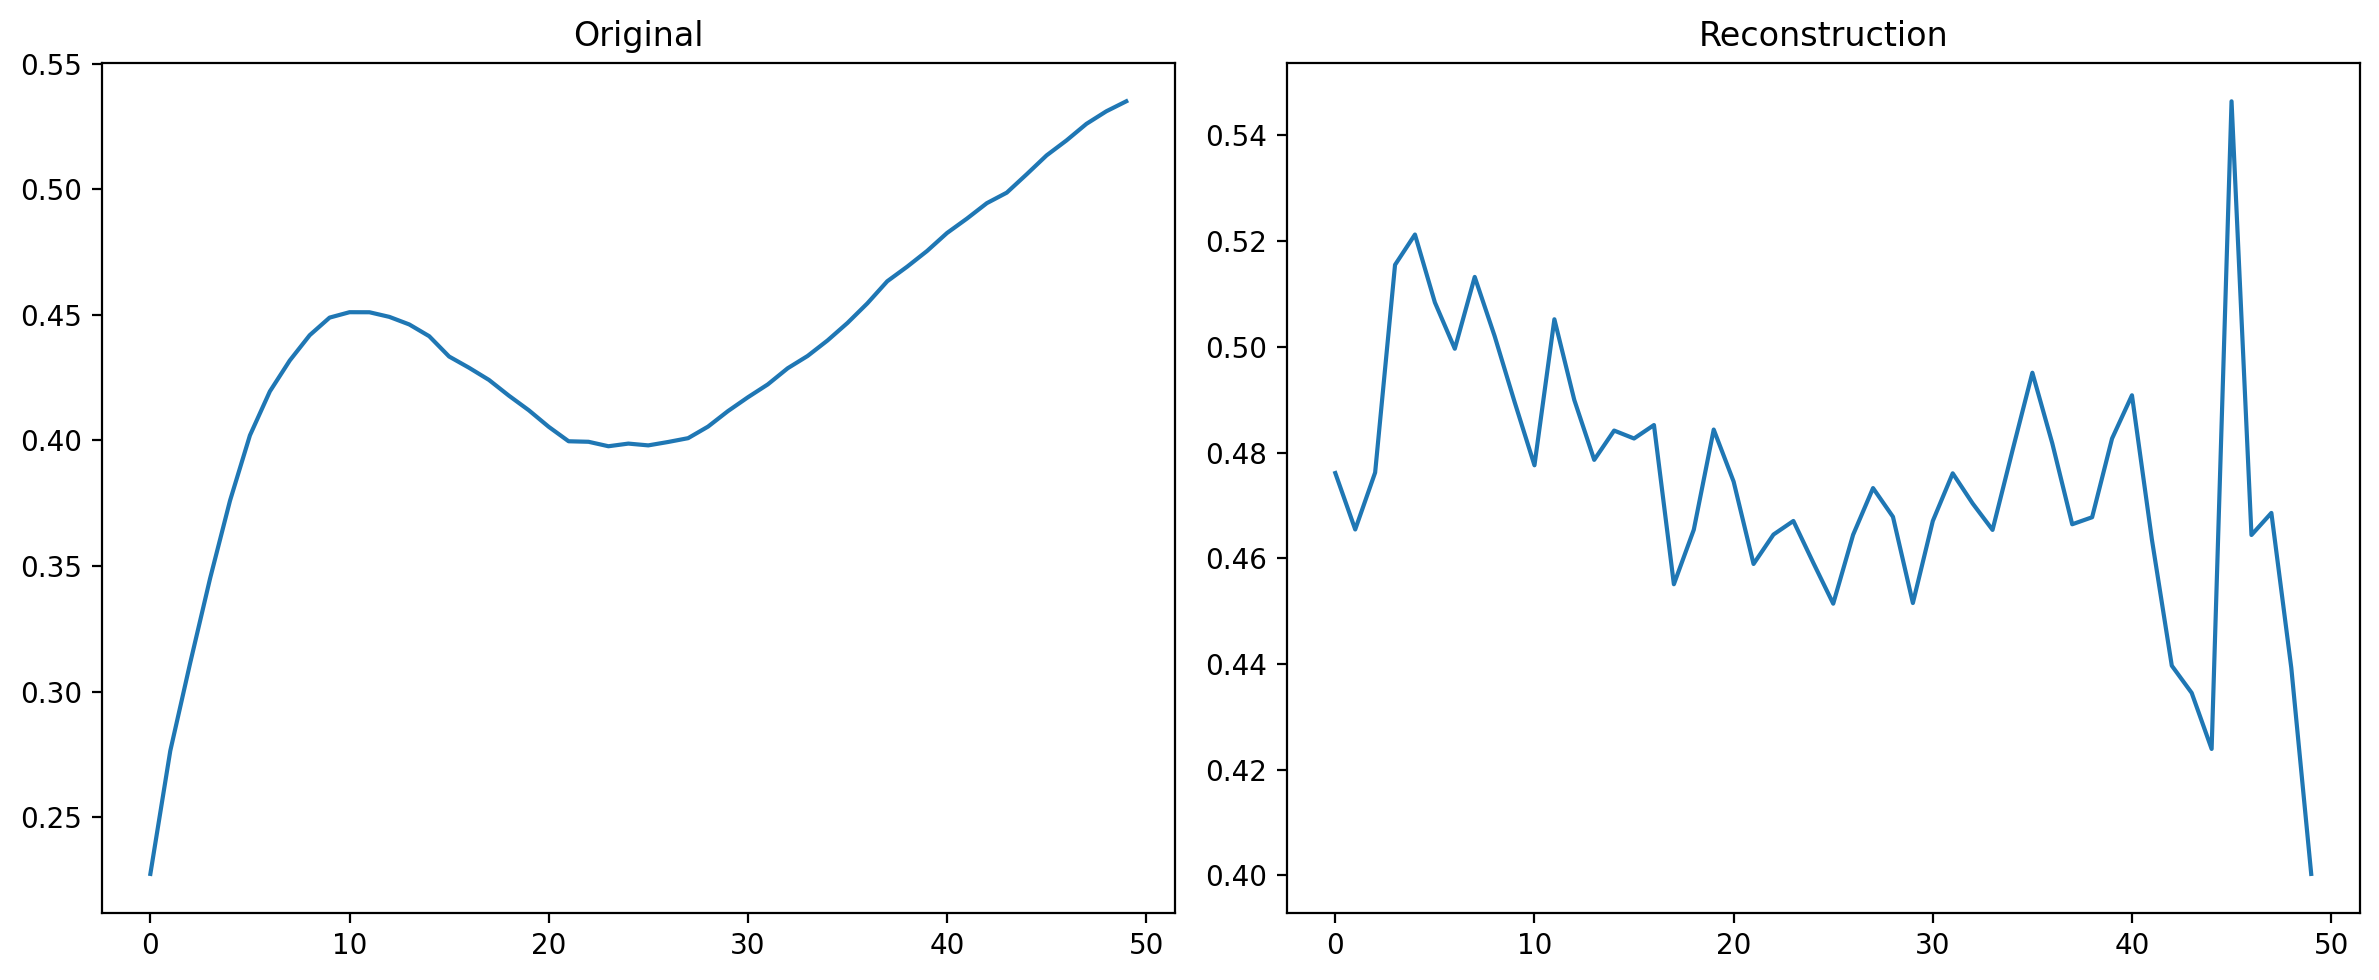

No age predictions available
No site predictions available


In [17]:
# Define the path to your saved model
model_path = "model_weights/combo_ld32_drV0.0_drA0.0_drS0.0_wr1.0_wkl1.0_wa5.0_ws2.0.pth"  # Replace with your actual path

# 2. Initialize your model architecture (with the same parameters used during training)
latent_dim = 32  # Match what was used in training
dropout = 0.0    # VAE dropout
age_dropout = 0.0
site_dropout = 0.0
num_sites = 4    # Adjust based on your dataset
input_channels = 1
sequence_length = 50  # Adjust based on your data

# Create model components
vae = Conv1DVariationalAutoencoder_fa(latent_dims=latent_dim, dropout=dropout)
age_predictor = AgePredictorCNN(input_channels=input_channels, sequence_length=sequence_length, dropout=age_dropout)
site_predictor = SitePredictorCNN(num_sites=num_sites, input_channels=input_channels, sequence_length=sequence_length, dropout=site_dropout)

# Create combined model
combined_model = CombinedVAE_Predictors(vae, age_predictor, site_predictor)

# 3. Load the weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
state_dict = torch.load(model_path, map_location=device)
combined_model.load_state_dict(state_dict)
combined_model.to(device)
combined_model.eval()  # Set to evaluation mode

# 4. Load sample data you want to reconstruct (adjust based on your data loading process)
# For example, get a batch from your test dataloader
test_loader = test_loader_raw  # Your test data loader
test_batch = next(iter(test_loader))
test_data = test_batch[0].to(device)  # Assuming first item is the data tensor

# 5. Generate reconstructions
with torch.no_grad():  # No need to track gradients for inference
    reconstructions, mean, logvar, age_preds, site_preds = combined_model(test_data, grl_alpha=0.0)  # grl_alpha doesn't matter in eval mode

print(f"Reconstructed shape: {reconstructions.shape}")
print(f"Mean shape: {mean.shape}")
print(f"Logvar shape: {logvar.shape}")
print(f"Age predictions shape: {age_preds[0]}")
print(f"Site predictions shape: {site_preds[0]}")
print("age real", test_loader_raw.dataset[0][1][0])
print("site real", test_loader_raw.dataset[1][1][1])

# 6. Visualize the original data and reconstructions
import matplotlib.pyplot as plt
import numpy as np

# Helper function to plot a sample and its reconstruction
def plot_sample_reconstruction(original, reconstruction, sample_idx=0):
    plt.figure(figsize=(12, 5))
    
    # Get the data for the selected sample
    orig = original[sample_idx, 0].cpu().numpy()
    recon = reconstruction[sample_idx, 0].cpu().numpy()
    
    plt.subplot(1, 2, 1)
    plt.plot(orig)
    plt.title("Original")
    
    plt.subplot(1, 2, 2)
    plt.plot(recon)
    plt.title("Reconstruction")
    
    plt.tight_layout()
    plt.show()
    
    # Print predictions if available
    if 'age_preds' in locals():
        print(f"Predicted Age: {age_preds[sample_idx].item():.2f}")
    else:
        print("No age predictions available")
    if 'site_preds' in locals() and 'test_batch' in locals():
        site_softmax = torch.nn.functional.softmax(site_preds[sample_idx], dim=0)
        print(f"Site Prediction: {site_softmax.cpu().numpy()}")
        if len(test_batch) > 2:  # If ground truth is available
            print(f"True Site: {test_batch[2][sample_idx].item()}")
    else:
        print("No site predictions available")

# Plot the first sample
plot_sample_reconstruction(test_data, reconstructions)

# Plot multiple samples
for i in range(min(5, len(test_data))):
    plot_sample_reconstruction(test_data, reconstructions, sample_idx=i)